In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy

In [2]:
### let's load the data

const_data = np.loadtxt('MN_data.txt')

Xs, Ys, sigs = const_data.T

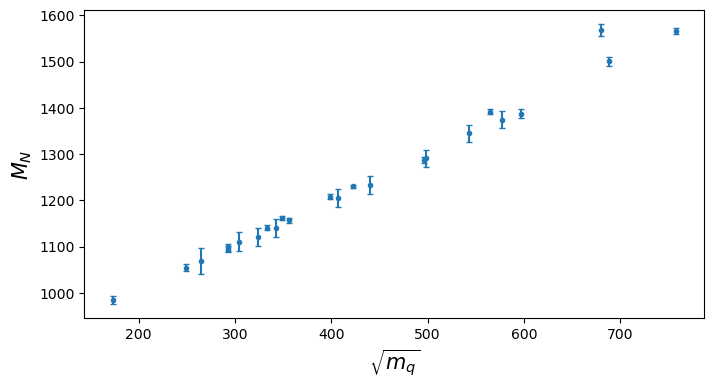

In [3]:
### let's plot the data

fig, axs = plt.subplots(1, 1, figsize=(8, 4))

axs.errorbar(Xs, Ys, yerr=sigs, capsize=2., marker='.', linestyle='None');
axs.set_ylabel('$M_N$', fontsize=15);
axs.set_xlabel('$\\sqrt{m_q}$', fontsize=15);

In [4]:
def chi2_line(slope_intercept):
    slope, intercept = slope_intercept

    line = slope*Xs + intercept
    chi20 = np.sum(pow((line - Ys)/sigs,2))
    return chi20

In [5]:
slope_intercept_guess = [1., 1000.]

optimal_line = scipy.optimize.minimize(chi2_line, slope_intercept_guess, method='nelder-mead')

In [6]:
optimal_line

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 64.50625782254032
             x: [ 1.024e+00  7.987e+02]
           nit: 55
          nfev: 105
 final_simplex: (array([[ 1.024e+00,  7.987e+02],
                       [ 1.024e+00,  7.987e+02],
                       [ 1.024e+00,  7.987e+02]]), array([ 6.451e+01,  6.451e+01,  6.451e+01]))

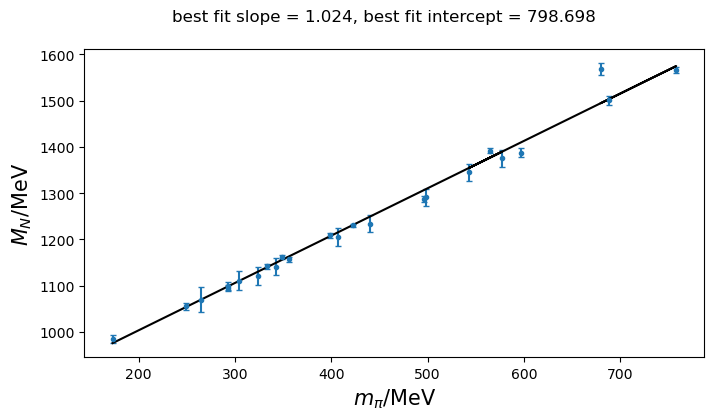

In [7]:
### let's plot the data

fig, axs = plt.subplots(1, 1, figsize=(8, 4))

axs.errorbar(Xs, Ys, yerr=sigs, capsize=2., marker='.', linestyle='None');
axs.set_ylabel('$M_N$/MeV', fontsize=15);
axs.set_xlabel('$m_\\pi$/MeV', fontsize=15);

optimal_slope, optimal_intercept = optimal_line.x
axs.plot(Xs, optimal_slope*Xs + optimal_intercept, color='k');

fig.suptitle('best fit slope = {:0.3f}, best fit intercept = {:0.3f}'.format(optimal_slope, optimal_intercept));